In [1]:
import numpy as np
import pandas as pd
import scipy.stats as stats
import ScraperFC as sfc
import statistics as stat
import matplotlib.pyplot as plt
from mplsoccer import PyPizza, add_image, FontManager
from adjustText import adjust_text
from pyfonts import load_google_font
font = load_google_font("DotGothic16")

In [5]:
ss = sfc.Sofascore()
player_data = ss.scrape_player_league_stats("25/26", "England Premier League")
player_data.head()

,accurateChippedPasses,accurateCrosses,accurateCrossesPercentage,accurateFinalThirdPasses,accurateLongBalls,accurateLongBallsPercentage,accurateOppositionHalfPasses,accurateOwnHalfPasses,accuratePasses,accuratePassesPercentage,...,totalShots,totwAppearances,touches,wasFouled,yellowCards,yellowRedCards,player,team,player id,team id
0,152,55,30.05,662,138,60.00,1089,550,1639,82.20,...,85,7,2647,35,5,0,Bruno Fernandes,Manchester United,288205,35
1,6,0,0.00,5,17,27.87,12,56,68,60.71,...,0,1,146,0,0,0,Max Weiss,Burnley,1128801,6
2,66,47,26.40,534,88,48.09,1062,803,1865,87.31,...,40,4,2769,11,3,0,Declan Rice,Arsenal,856714,42
3,78,21,25.61,446,81,60.45,772,478,1250,86.15,...,42,5,2034,75,6,0,Bruno Guimarães,Newcastle United,866469,39
4,94,1,16.67,340,90,68.70,861,597,1458,90.11,...,16,2,1869,31,3,0,Rodri,Manchester City,827606,17


In [6]:
detail = pd.read_csv("player_details.csv")

In [7]:
data = player_data
players = detail

In [8]:
players.head()

,id,name,team_name,team_id,position,positions_detailed,weight,height,dob,preferred_foot,country,contract_until,market_value,market_value_currency,career_stats
0,839956,Erling Haaland,Manchester City,17,F,['ST'],87.0,194.0,2000-07-21 00:00:00+00:00,Left,Norway,2034-06-30 00:00:00+00:00,218000000.0,EUR,year startYear endYear statistics.accu...
1,159665,Mohamed Salah,Liverpool,44,M,['RW'],NaN,175.0,1992-06-15 00:00:00+00:00,Left,Egypt,2027-06-30 00:00:00+00:00,29000000.0,EUR,year startYear endYear statistics.accu...
2,982780,Cole Palmer,Chelsea,38,M,"['AM', 'RW']",NaN,185.0,2002-05-06 00:00:00+00:00,Left,England,2033-06-30 00:00:00+00:00,101000000.0,EUR,year startYear endYear statistics.accu...
3,288205,Bruno Fernandes,Manchester United,35,M,"['AM', 'MC', 'DM']",65.0,179.0,1994-09-08 00:00:00+00:00,Right,Portugal,2027-06-30 00:00:00+00:00,37000000.0,EUR,year startYear endYear statistics.accu...
4,1597265,Estêvão,Chelsea,38,M,['RW'],62.0,176.0,2007-04-24 00:00:00+00:00,Left,Brazil,2033-06-30 00:00:00+00:00,82000000.0,EUR,year startYear endYear statistics.accu...


In [9]:
#joined_data = data.join(players.set_index('name'), on='player', how='inner')

In [10]:
#joined_data = joined_data[joined_data['minutesPlayed']> 800]

In [11]:
#joined_data.columns.to_list()

In [12]:
joined_data = player_data

In [13]:
defensive_action = joined_data[['player','clearances','tackles','interceptions','ballRecovery']]
offensive_action = joined_data[['player','totalShots','expectedGoals','expectedAssists','shotsOnTarget','keyPasses', 'bigChancesCreated']]
passes_accu = joined_data[['player','accuratePassesPercentage']]
pass_range = joined_data[['player','accurateLongBalls','totalLongBalls']]
dribble = joined_data[['player','successfulDribbles','successfulDribblesPercentage']]
Gduels = joined_data[['player','groundDuelsWon']]
Gduels_rate = joined_data[['player','groundDuelsWonPercentage']]
Aduels = joined_data[['player','aerialDuelsWon']]
Aduels_rate = joined_data[['player','aerialDuelsWonPercentage']]
creativity = joined_data[['player','keyPasses','bigChancesCreated','expectedAssists']]


In [16]:
def percentile(player_name, param):
    nums = {
        'defensive_action':0,
        'passes_accu' : 0,
        'pass_range' : 0,
        'dribble':0,
        'Gduels':0,
        'Gduels_rate':0,
        'Aduels':0,
        'Aduels_rate':0,
        'creativity':0
    }
    ls = [defensive_action, passes_accu, pass_range, dribble, Gduels,Gduels_rate,Aduels,Aduels_rate, creativity]
    ls2 = ['defensive_action', 'passes_accu', 'pass_range', 'dribble', 'Gduels','Gduels_rate','Aduels','Aduels_rate', 'creativity']
    i = 0
    for df in ls:
        num = []
        for col in df.columns:
            if col != 'player':
                target = df[df['player'] == player_name]
                total = df[col].dropna().to_list()
                n = target[col].values[0]
                percentile = stats.percentileofscore(total, n)
                num.append(percentile)
        number = np.mean(num)
        nums[ls2[i]] = number
        i+=1
    param = list(nums.keys())
    val = [int(nums['defensive_action']), int(nums['passes_accu']), int(nums['pass_range']), int(nums['dribble']), int(nums['Gduels']),int(nums['Gduels_rate']),int(nums['Aduels']), int(nums['Aduels_rate']), int(nums['creativity'])]
    return param, val

In [17]:
def vis(params, vals, name):
    params = params
    values = vals
        #[int(nums['defensive_action']), int(nums['passes_accu']), int(nums['pass_range']), int(nums['dribble']), int(nums['duels']), int(nums['creativity'])]
    
    baker = PyPizza(
        params=params,                  # list of parameters
        straight_line_color="#F2F2F2",  # color for straight lines
        straight_line_lw=1,             # linewidth for straight lines
        last_circle_lw=0,               # linewidth of last circle
        other_circle_lw=0,              # linewidth for other circles
    )
    
    fig, ax = baker.make_pizza(
        values,               # list of percentile values for slice sizes
        figsize=(8, 8), # actual values to display on chart
        color_blank_space="same",        # use same color to fill blank space
        blank_alpha=0.4,                 # alpha for blank-space colors
        kwargs_slices=dict(
            facecolor="lightcoral", edgecolor="#F2F2F2",
            zorder=2, linewidth=1
        ),                               # values to be used when plotting slices
        kwargs_params=dict(
            color="#000000", fontsize=12,
            va="center"
        ), 
        kwargs_values=dict(
            color="#000000", fontsize=11,
            zorder=3,
            bbox=dict(
                edgecolor="#000000", facecolor="lightcoral",
                boxstyle="round,pad=0.2", lw=1
            )
        ) 
    )
    
    fig.text(
        0.515, 0.97, name, size=18,
        ha="center",color="#000000"
    )
    
    plt.savefig(f'C:\\Users\\yukiw\\Pictures\\douga\\{name}.png')
    

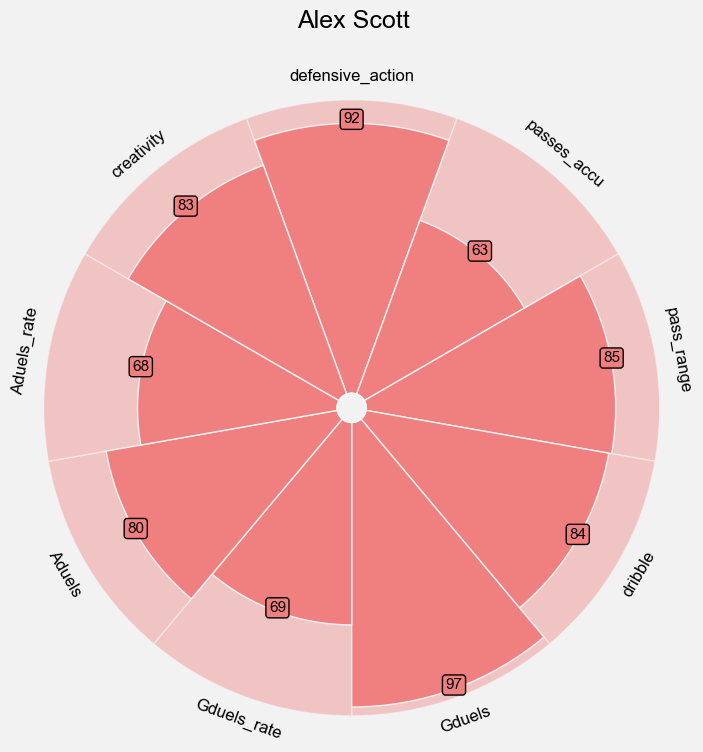

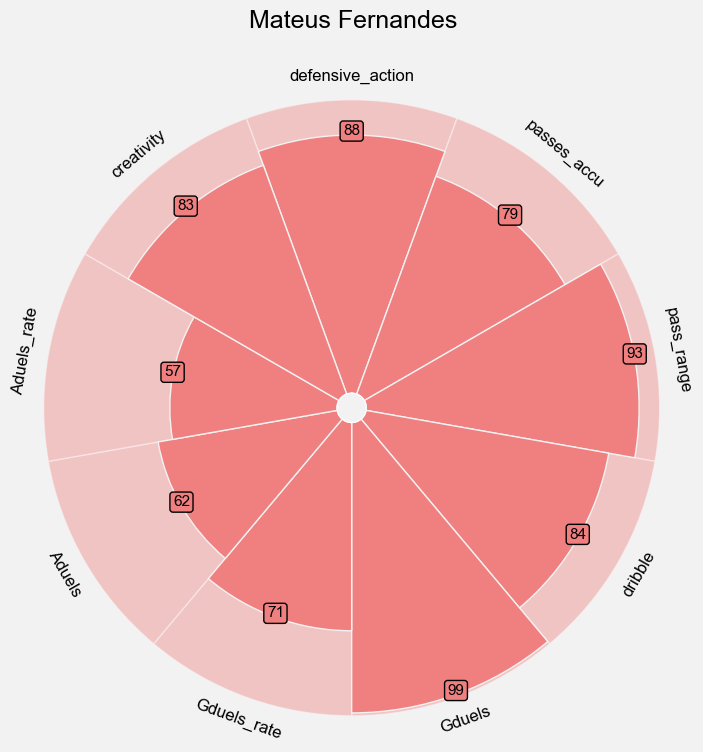

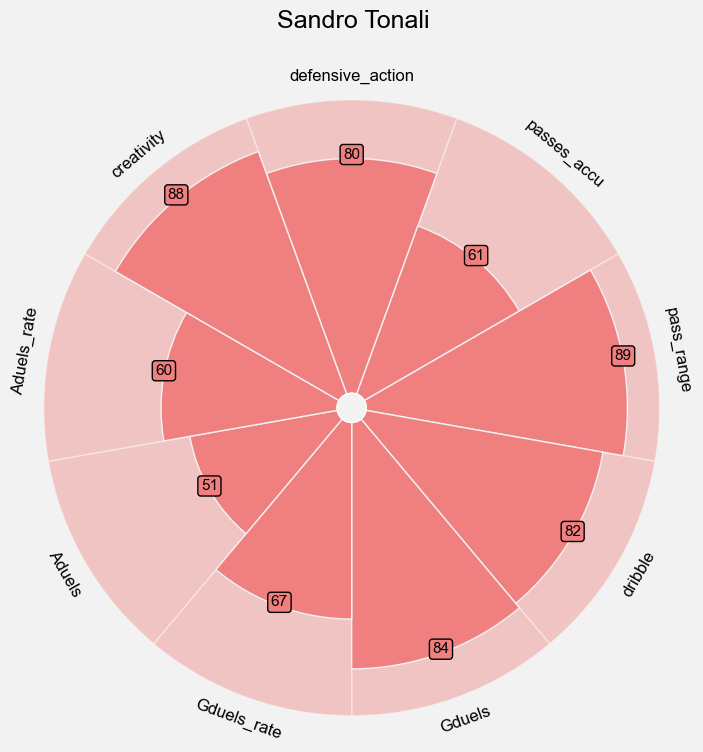

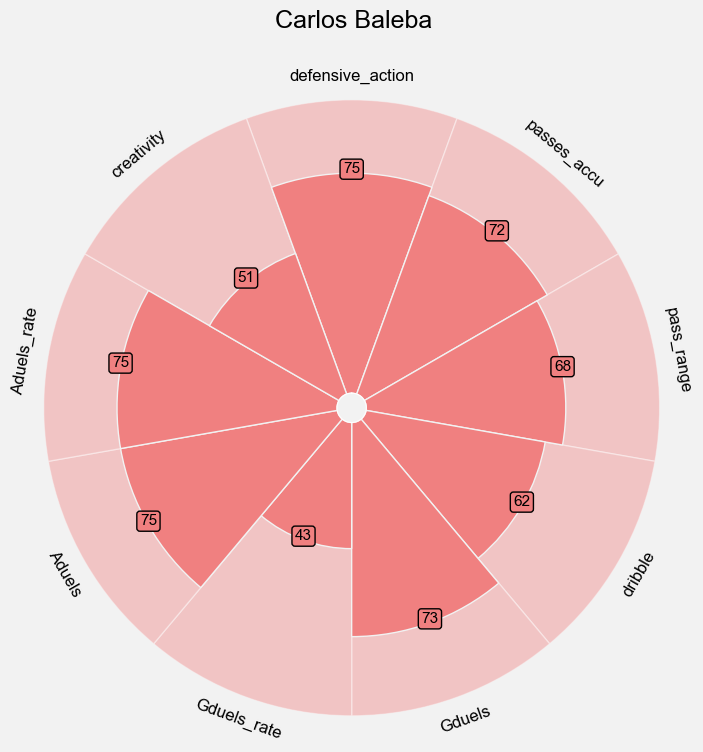

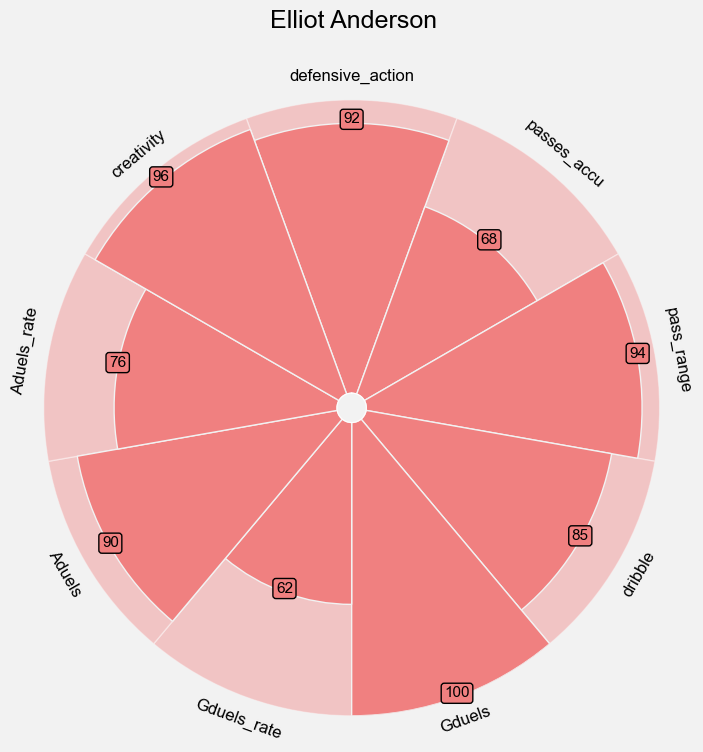

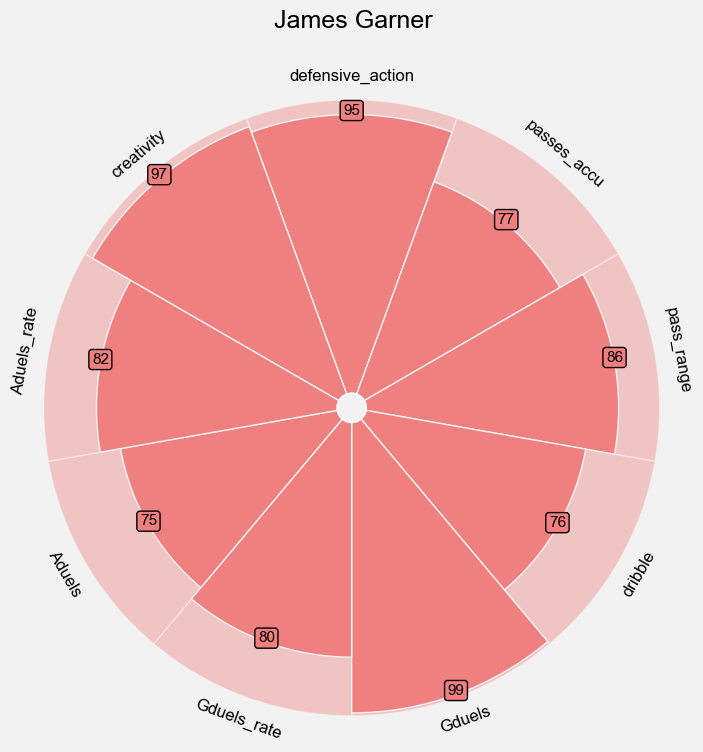

In [22]:
liiist = ['Alex Scott', 'Mateus Fernandes', 'Sandro Tonali', 'Carlos Baleba', 'Elliot Anderson', 'James Garner']
param = [defensive_action, passes_accu, pass_range, dribble, Gduels,Gduels_rate,Aduels,Aduels_rate, creativity]


for a in liiist:
    x,y = percentile(a, param)
    vis(x,y,a)

In [ ]:
target = joined_data[joined_data['position'] == 'M']

In [ ]:
plt.hist(target['accuratePassesPercentage'])

In [ ]:
target.columns.to_list()

In [ ]:
a = target['aerialDuelsWonPercentage']
x = a.to_list()
b  = target['aerialDuelsWon'] / 90
y = b.to_list()
names = target['player'].to_list()
n_top = 15

fig, ax = plt.subplots(figsize=(60,40))
ax.scatter(x, y)

combined_score = x + y 
top_indices = np.argsort(combined_score)[-n_top:]

# ...existing code...
texts = []             # will hold matplotlib.text.Text objects
seen = set()           # hold rounded coordinate tuples to detect near-duplicates
for i, label in enumerate(names):
    xi = x[i]
    yi = y[i]
    coord = (round(xi, 6), round(yi, 6))  # 6桁で丸めて近さを判定

    # 重複があれば少しオフセットする
    if coord in seen:
        yi_display = yi + yi * 0.01
    else:
        yi_display = yi

    if label == 'Sandro Tonali':
        t = plt.text(xi, yi_display, label, fontsize=15)
    else:
        t = plt.text(xi, yi_display, label, fontsize=7)

    texts.append(t)
    seen.add(coord)

# adjust_text に Text オブジェクトのリストを渡す
adjust_text(texts, arrowprops=dict(arrowstyle='->', color='red', lw=0.5))
plt.show()
# ...existing code...


In [ ]:
c = target[target['groundDuelsWon'] / 90 > 1.0]
d = target[target['aeri'] / 90 > 0.3]

c1 = c['player']
d1 = d['player']
names = pd.concat([c1,d1]).unique().tolist()

c = c['groundDuelsWon']
d = d['successfulDribbles']

c = c.to_list()
d = d.to_list()

fig, ax = plt.subplots(figsize=(60,40))
ax.scatter(x, y)

combined_score = x + y 
top_indices = np.argsort(combined_score)[-n_top:]

# 4. Annotate only top points
for i, label in enumerate(names):
    plt.text(c[i], d[i], label, fontsize=7)

plt.show()

In [ ]:
len(d)

In [ ]:
len(names)